# 3.2 Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re  #for removing pattern or special symbol #import regex library

In [19]:
#read the CSV file into a DataFrame
df = pd.read_csv('bilingual_hatespeech.csv')

#display the first 5 rows to check the data
df.head()

,text,label,source,lang
0,<number> u0 laughing my ass off wow fuck you,0,HateXplain,en
1,<number> th century mayhem and lawlessness had...,0,HateXplain,en
2,<number> h ada retard au work shessh,0,HateXplain,en
3,<number> stop that wave feminism let us vote a...,0,HateXplain,en
4,<number> okay do not put out patch notes and y...,0,HateXplain,en


In [20]:
#general info of dataset (rows, columns, data types)
print("Dataset info:")
df.info()

#check for missing values 
print("\nNumber of missing values: ")
print(df.isnull().sum())

#check for unique values 
print("\nNumber of unique values: ")
print(df.nunique())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26985 entries, 0 to 26984
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    26985 non-null  object
 1   label   26985 non-null  int64 
 2   source  26985 non-null  object
 3   lang    26985 non-null  object
dtypes: int64(1), object(3)
memory usage: 843.4+ KB

Number of missing values: 
text      0
label     0
source    0
lang      0
dtype: int64

Number of unique values: 
text      26985
label         2
source        5
lang          2
dtype: int64


**3.2.1 Class Balance Across Different Language**

In [21]:
#count the unique values in the 'lang' column
language_counts = df['lang'].value_counts()

print("\nLanguage Counts : ")
print(language_counts)


Language Counts : 
lang
en    13609
ms    13376
Name: count, dtype: int64


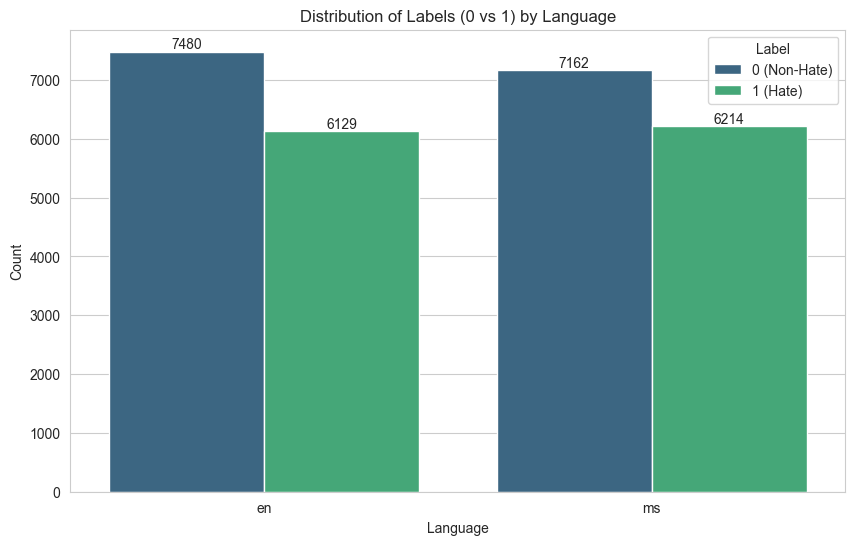

In [22]:
#set the background
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

#create the plot and assign it to 'ax'
ax = sns.countplot(data=df, x='lang', hue='label', palette='viridis')

#loop through the bars and add the labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Labels (0 vs 1) by Language')
plt.xlabel('Language')
plt.ylabel('Count')
plt.legend(title='Label', labels=['0 (Non-Hate)', '1 (Hate)'])

plt.show()

**3.2.3 Vocabulary Diversity (using TTR)**

In [24]:
#combine all text in dataset into one string and then split
all_text_combined = " ".join(df['text'].astype(str)).lower().split()

#calculate total words(tokens) and unique words(type)
total_tokens = len(all_text_combined)
unique_types = len(set(all_text_combined))

#ratio calculation
ttr = unique_types / total_tokens

print(f"Total Words: {total_tokens}")
print(f"Unique Words: {unique_types}")
print(f"Type-Token Ratio (TTR): {ttr:.4}")

Total Words: 576860
Unique Words: 46020
Type-Token Ratio (TTR): 0.07978


# 3.3 Data Preprocessing

**3.3.1 Tag Standardization AND Whitespace Handling**

In [2]:
from collections import Counter  #count frequency of items

#define a function to find everything inside <...>
def find_tags(text):
    if pd.isna(text):
        return []
    #regex (regular expression) to capture content between < and >
    return re.findall(r'<[^>]+>', str(text))

#apply the function and count results
all_tags = df['text'].apply(find_tags)
flat_tags = [tag for sublist in all_tags for tag in sublist]
tag_counts = Counter(flat_tags)

#display the results
print(f"Total tags found: {len(flat_tags)}")
print("Frequency of each tag:")
for tag, count in tag_counts.most_common():
    print(f"{tag}: {count}")

#highlight the weird tags
expected_tags = {'<user>', '<number>', '<time>'}
weird_tags = [t for t in tag_counts if t not in expected_tags]

print("\n Non-Standard Tags :")
print(weird_tags)

Total tags found: 7972
Frequency of each tag:
<user>: 5171
<number>: 2421
<percent>: 141
<date>: 50
<censored>: 50
<money>: 37
<happy>: 27
<time>: 25
<sad>: 15
<wink>: 8
<laugh>: 8
<phone>: 3
<annoyed>: 2
<email>: 2
<surprise>: 2
<will>: 1
<angel>: 1
<kiss>: 1
<tong>: 1
< 3 dan gembira streaming ulang tahun<user>: 1
< 3 treasuremakerselcaday teumeselcaday tmsd parkjihoon<user>: 1
< muzik teras >: 1
< berwarnawarni trauma >: 1
< 3 pic dosen untuk<user>: 1
< >: 1

 Non-Standard Tags :
['<date>', '<money>', '<percent>', '<censored>', '<happy>', '<wink>', '<laugh>', '<will>', '<sad>', '<annoyed>', '<phone>', '<email>', '<angel>', '<kiss>', '<tong>', '<surprise>', '< 3 dan gembira streaming ulang tahun<user>', '< 3 treasuremakerselcaday teumeselcaday tmsd parkjihoon<user>', '< muzik teras >', '< berwarnawarni trauma >', '< 3 pic dosen untuk<user>', '< >']


In [3]:
def standardize_tags(text):  #define new function named 'srandardize_tags'
    if pd.isna(text):        #check for null value. safety measure
        return ""            
    text = str(text)         #convert input into string (e.g. '2025' is treated as string not number)
    
    #covert specififc tags into standard one
    text = text.replace('<date>', '<time>')
    text = text.replace('<money>', '<number>')
    text = text.replace('<percent>', '<number>')
    text = text.replace('<phone>', '<user>')
    text = text.replace('<email>', '<user>')
    
    #list tags we want to keep (standard tags + emotion tags)
    keep_tags = ['<user>', '<number>', '<time>','<happy>', '<sad>', '<laugh>', '<wink>','<annoyed>', '<surprise>', '<angel>', '<kiss>', '<tong>']
    
    #remove tags that is not in the keep list
    def replace_func(match):
        tag = match.group(0)    #computer holds a tag if found
        if tag in keep_tags:
            return tag          #return the tag as is (keep it)
        else:
            return ""           #replace with empty string (delete)
            
    #apply the replacement
    text = re.sub(r'<[^>]+>', replace_func, text)
    
    #clean the extra space in the text
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply to your dataframe
df['text_cleaned'] = df['text'].apply(standardize_tags)

# Check the results
print("Sample of the cleaned text:")
print(df[['text', 'text_cleaned']].sample(5))

Sample of the cleaned text:
                                                    text  \
16954  dan minzy  tampil mengejutkan penonton dengan ...   
10866  maybe a jew doc fixed him up if a kike kept me...   
11524  professional white married to a wetback he the...   
14177  vandalisme , douching , dan faggotry tidak dit...   
2648   <user> you  reply going to kill all of your ol...   

                                            text_cleaned  
16954  dan minzy tampil mengejutkan penonton dengan m...  
10866  maybe a jew doc fixed him up if a kike kept me...  
11524  professional white married to a wetback he the...  
14177  vandalisme , douching , dan faggotry tidak dit...  
2648   <user> you reply going to kill all of your old...  


**3.3.2 Relabelling using BERT**

In [4]:
#install general dependencies
!pip install pandas transformers openai protobuf sentencepiece

#uninstall existing PyTorch versions to avoid version conflicts
%pip uninstall -y torch torchvision torchaudio

#force install the specific PyTorch version with CUDA 12.4 support (Required for GPU acceleration)
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

#verify installation
import torch
print(f"PyTorch Version: {torch.__version__}")
print("GPU Available:", torch.cuda.is_available())  #if prints true meaning the gpu is ready

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp312-cp312-win_amd64.whl.metadata (6.8 kB)
Using cached https://download.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp312-cp312-win_amd64.whl (2532.3 MB)
Using cached https://download.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp312-cp312-win_amd64.whl (6.1 MB)
Using cached https://download.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp312-cp312-win_amd64.whl (4.2 MB)
Note: you may need to restart the kernel to use updated packages.
PyTorch Version: 2.6.0+cu124
GPU Available: True


In [5]:
#BERT relabelling
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm

#check if device run on cpu or gpu now
device = 0 if torch.cuda.is_available() else -1
print(f"Processing on: {'GPU' if device == 0 else 'CPU'} (Device Index: {device})")

C:\Users\User\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing on: GPU (Device Index: 0)


In [6]:
#load the pre trained model
classifier = pipeline("text-classification", 
                      model="unitary/multilingual-toxic-xlm-roberta", 
                      top_k=None, 
                      device=device)

#define the labelling function
def get_bert_label(text):
    try:
        #make sure text is string (handle potential NaN)
        text_str = str(text)
        
        #max tokens =512 due to BERT limits
        output = classifier(text_str, truncation=True, max_length=512)
        
        #extract scores
        scores = {item['label']: item['score'] for item in output[0]}
        
        #logic: assign label 1 if 'toxic' score is > 0.5, else 0
        return 1 if scores.get('toxic', 0) > 0.5 else 0
    except Exception as e:
        return None

#apply to dataframe
tqdm.pandas()
df['Bert_New_Label'] = df['text_cleaned'].progress_apply(get_bert_label)

#save result into csv file
output_filename = 'bilingual_hatespeech_relabeled.csv'
df.to_csv(output_filename, index=False)
print(f"Done. relabeled dataset saved as '{output_filename}'.")

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset  7.94it/s]
100%|████████████████████████████████████████████████████████████████████████████| 26985/26985 [13:27<00:00, 33.43it/s]


Done. relabeled dataset saved as 'bilingual_hatespeech_relabeled.csv'.


**3.3.3. Relabelling using LLM (Flan T5)**

In [2]:
import pandas as pd
import torch
from transformers import pipeline, logging as hf_logging
import warnings
import os

#silence the annoying warnings
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

#load Data
df = pd.read_csv('bilingual_hatespeech_relabeled.csv') 
print(f"Loaded {len(df)} rows.")

#check Device
device = 0 if torch.cuda.is_available() else -1
print(f"Processing on: {'GPU' if device == 0 else 'CPU'}")

#load Model
print("Loading Flan-T5 Model...")
generator = pipeline("text2text-generation", 
                     model="google/flan-t5-large", 
                     device=device,
                     batch_size=32)

# --- 2. DEFINE BATCHING & SAVING LOGIC ---
def get_label_from_text(answer):
    answer = str(answer).lower().strip()
    if "yes" in answer: return 1
    elif "no" in answer: return 0
    else: return None

# We will process in chunks of 500 rows and save immediately
CHUNK_SIZE = 500
total_rows = len(df)
output_file = 'bilingual_hatespeech_relabeled_SAFE.csv'

print(f"Starting Incremental Relabeling. Saving to {output_file} every {CHUNK_SIZE} rows...")

# Prepare list to hold results temporarily
all_new_labels = [None] * total_rows # Placeholder list

# --- 3. THE LOOP ---
# We loop through the dataframe in chunks
for start_idx in range(0, total_rows, CHUNK_SIZE):
    end_idx = min(start_idx + CHUNK_SIZE, total_rows)
    
    # Get the small batch of text
    batch_texts = df['text_cleaned'].iloc[start_idx:end_idx].astype(str).tolist()
    
    # Create prompts
    prompts = [f"Is this text hate speech? Answer yes or no.\nText: {t}" for t in batch_texts]
    
    # Run inference on this small chunk
    batch_results = generator(prompts, batch_size=32, max_length=10)
    
    # Process answers
    chunk_labels = []
    for out in batch_results:
        # --- FIX: ROBUST EXTRACTION ---
        # Checks if output is a list (standard) or dict (sometimes happens in chunks)
        if isinstance(out, list):
            ans = out[0]['generated_text']
        else:
            ans = out['generated_text']
            
        chunk_labels.append(get_label_from_text(ans))
    
    # Assign to our master list
    for i, label in enumerate(chunk_labels):
        all_new_labels[start_idx + i] = label
        
    # --- INCREMENTAL SAVE ---
    # We update the dataframe in memory
    df.loc[start_idx:end_idx-1, 'LLM_New_Label'] = chunk_labels
    
    # Save to disk
    if end_idx % 1000 == 0 or end_idx == total_rows:
        df.to_csv(output_file, index=False)
        print(f"-> Progress: Processed & Saved rows up to {end_idx}/{total_rows}")

print("DONE! Final file saved.")

C:\Users\User\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 26985 rows.
Processing on: GPU
Loading Flan-T5 Model...
Starting Incremental Relabeling. Saving to bilingual_hatespeech_relabeled_SAFE.csv every 500 rows...
-> Progress: Processed & Saved rows up to 1000/26985
-> Progress: Processed & Saved rows up to 2000/26985
-> Progress: Processed & Saved rows up to 3000/26985
-> Progress: Processed & Saved rows up to 4000/26985
-> Progress: Processed & Saved rows up to 5000/26985
-> Progress: Processed & Saved rows up to 6000/26985
-> Progress: Processed & Saved rows up to 7000/26985
-> Progress: Processed & Saved rows up to 8000/26985
-> Progress: Processed & Saved rows up to 9000/26985
-> Progress: Processed & Saved rows up to 10000/26985
-> Progress: Processed & Saved rows up to 11000/26985
-> Progress: Processed & Saved rows up to 12000/26985
-> Progress: Processed & Saved rows up to 13000/26985
-> Progress: Processed & Saved rows up to 14000/26985
-> Progress: Processed & Saved rows up to 15000/26985
-> Progress: Processed & Saved rows

**3.3.4 Relabelling Logic (Majority Vote)**

In [29]:
df = pd.read_csv('bilingual_hatespeech_relabeled_SAFE.csv')

#define and create a list of column involved
columns_to_vote = ['label', 'Bert_New_Label', 'LLM_New_Label']

#apply the logic of majority vote
# .mode(axis=1):calculates the most frequent values for each row  AND [0] means return the first value (tie safety measure)
df['majority_vote'] = df[columns_to_vote].mode(axis=1)[0]

#make sure the return value is save in interger
df['majority_vote'] = df['majority_vote'].astype(int)

#save to previous csv file
df.to_csv('bilingual_hatespeech_relabeled_SAFE.csv', index=False)

print("new 'majority_vote' column have created.")
print(df[['label', 'Bert_New_Label', 'LLM_New_Label', 'majority_vote']].sample(20))

new 'majority_vote' column have created.
       label  Bert_New_Label  LLM_New_Label  majority_vote
1461       0               0              0              0
25033      1               1              0              1
19183      0               0              0              0
12187      1               0              1              1
24283      1               0              0              0
15134      0               0              0              0
8793       1               1              1              1
2554       0               1              1              1
25752      1               1              1              1
23854      1               0              0              0
19987      0               0              0              0
15478      0               1              0              0
3654       0               1              1              1
24242      1               1              0              1
20460      0               0              0              0
8062       1   

**3.3.5 Data Shuffling**

In [31]:
#shuffle the dataset 
#frac=1 means '100% of rows', random_state=42 ensures the shuffle is the same every time
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

#save to a new csv file
df_shuffled.to_csv('shuffled_dataset.csv', index=False)

print("done. first 5 rows of shuffled data:")
print(df_shuffled.head())

done. first 5 rows of shuffled data:
                                                text  label      source lang
0  italy is for italians get the immigrants to go...      1  HateXplain   en
1  hrs trafik perlahan dari pagoh ke udara hitam ...      0       HateM   ms
2  <user> i just do not think you know how the ju...      0  HateXplain   en
3                              blow these niggas out      0  HateXplain   en
4   baru  bapak2 kuli bangunan , ketemu pas dia p...      0    Snapshot   ms


**3.3.6 Splitting Data**

In [32]:
from sklearn.model_selection import train_test_split

#load the shuffled dataset
df = pd.read_csv('shuffled_dataset.csv')

#define target as 'majority vote' so it will be split evenly between '0' and '1'
y = df['majority_vote']

#split the whole data frame 
#20% for temp and 80% for train
train_df, temp_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

#further split the temp into 10%test and 10% validation
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['majority_vote']
)

#to verify again
total = len(df)
print(f"Total Rows: {total}")
print(f"Training:   {len(train_df)} ({len(train_df)/total:.0%})")
print(f"Validation: {len(val_df)}   ({len(val_df)/total:.0%})")
print(f"Testing:    {len(test_df)}   ({len(test_df)/total:.0%})")

#save to seperate csv file
train_df.to_csv('train_data.csv', index=False)
val_df.to_csv('validation_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

print("\ndone. all csv files has been saved.")

KeyError: 'majority_vote'

**3.3.7 Feature Extraction / Input Representation**

**-Tokenization and Padding-**

In [13]:
!pip install tensorflow


   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/331.9 MB 5.0 MB/s eta 0:01:06
    --------------------------------------- 4.5/331.9 MB 11.7 MB/s eta 0:00:29
   - -------------------------------------- 8.4/331.9 MB 14.1 MB/s eta 0:00:24
   - -------------------------------------- 11.0/331.9 MB 15.6 MB/s eta 0:00:21
   - -------------------------------------- 13.6/331.9 MB 13.6 MB/s eta 0:00:24
   - -------------------------------------- 16.3/331.9 MB 13.3 MB/s eta 0:00:24
   -- ------------------------------------- 21.0/331.9 MB 14.7 MB/s eta 0:00:22
   --- ------------------------------------ 27.8/331.9 MB 17.1 MB/s eta 0:00:18
   --- ------------------------------------ 31.5/331.9 MB 16.9 MB/s eta 0:00:18
   ---- ----------------------------------- 36.4/331.9 MB 17.7 MB/s eta 0:00:17
   ----- ---------------------------------- 42.7/331.9 MB 19.

In [27]:
import pandas as pd
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- 1. CONFIGURATION (Hyperparameters) ---
# MAX_WORDS: The model will only learn the top 20,000 most frequent words. 
# Rare typos or unique names will be ignored (treated as "Unknown").
MAX_WORDS = 20000 

# MAX_LEN: Every single comment will be forced to be exactly 100 numbers long.
# If shorter, we add zeros. If longer, we cut it.
MAX_LEN = 100 

# --- 2. LOAD DATA ---
print("Loading data...")
train_df = pd.read_csv('train_data.csv')
val_df   = pd.read_csv('validation_data.csv')
test_df  = pd.read_csv('test_data.csv')

# Ensure text is string format (prevents crash if empty row exists)
X_train_text = train_df['text'].astype(str)
X_val_text   = val_df['text'].astype(str)
X_test_text  = test_df['text'].astype(str)

# --- 3. BUILD THE TOKENIZER ---
print("Training Tokenizer...")
# We create the "Translator" object. oov_token="<OOV>" handles words the model hasn't seen before.
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# CRITICAL: We fit ONLY on the Training data. 
# This prevents "cheating" (Data Leakage). The model builds its dictionary 
# knowing only what is in the training set.
tokenizer.fit_on_texts(X_train_text)

# Save the tokenizer so we can use it later for the web app/demo
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique words in the training vocabulary.")

# --- 4. CONVERT TEXT TO SEQUENCES ---
# Replace words with their ID numbers (e.g., "benci" -> 45)
train_seq = tokenizer.texts_to_sequences(X_train_text)
val_seq   = tokenizer.texts_to_sequences(X_val_text)
test_seq  = tokenizer.texts_to_sequences(X_test_text)

# --- 5. PADDING (Make them all the same shape) ---
# padding='post' means we add zeros at the END (e.g., [45, 12, 0, 0])
# truncating='post' means we cut the END if it's too long
X_train_padded = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_padded   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("\nSuccess! Data is tokenized and padded.")
print(f"Shape of Training Matrix: {X_train_padded.shape}")
print(f"Example Raw Text: {X_train_text.iloc[0]}")
print(f"Example Converted: {X_train_padded[0]}")

Loading data...
Training Tokenizer...
Found 40220 unique words in the training vocabulary.

Success! Data is tokenized and padded.
Shape of Training Matrix: (21588, 100)
Example Raw Text: saya tidak mempertahankan apaapa untuk anda . anda berat sebelah dan berselindung . berhenti mengambil pertikaian saya atau diharamkan .
Example Converted: [    7    27  3391   438    35     6     6  2263  1320    18 12579   228
   710 18054     7   171  2086     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]


**Embedding Matrix**

In [15]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   ------- -------------------------------- 4.5/24.4 MB 20.7 MB/s eta 0:00:01
   -------------- ------------------------- 8.9/24.4 MB 18.4 MB/s eta 0:00:01
   ----------------------- ---------------- 14.2/24.4 MB 20.7 MB/s eta 0:00:01
   ----------------------------------- ---- 21.8/24.4 MB 26.0 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 23.8 MB/s eta 0:00:00


In [28]:
import numpy as np
from gensim.models import Word2Vec

# --- 1. CONFIGURATION ---
# Embedding Dimension: How "complex" is the meaning? 100 is standard for small datasets.
EMBEDDING_DIM = 100 

# --- 2. PREPARE DATA FOR WORD2VEC ---
# Word2Vec needs a list of lists of words: [['i', 'hate', 'you'], ['saya', 'suka', 'awak']]
# We reuse the text from your train dataframe
sentences = [text.split() for text in train_df['text'].astype(str)]

print(f"Training Word2Vec on {len(sentences)} sentences...")

# --- 3. TRAIN WORD2VEC ---
# window=5: Look 5 words behind and ahead to understand context
# min_count=1: Even if a word appears once, try to learn it (since dataset is small)
# workers=4: Use parallel processing to go fast
w2v_model = Word2Vec(sentences, vector_size=EMBEDDING_DIM, window=5, min_count=1, workers=4)

print(f"Word2Vec trained! Vocabulary size: {len(w2v_model.wv.index_to_key)}")

# --- 4. CREATE EMBEDDING MATRIX ---
# This acts as the bridge between your Tokenizer (integers) and Word2Vec (vectors)

# Get the vocabulary from your Tokenizer (created in previous step)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for the padding (0)

# Create a matrix of all zeros
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

hits = 0
misses = 0

print("Building Embedding Matrix...")

# Loop through every word in your tokenizer
for word, i in word_index.items():
    # Check if this word exists in our new Word2Vec model
    if word in w2v_model.wv:
        # If yes, grab its vector and put it in the matrix
        embedding_matrix[i] = w2v_model.wv[word]
        hits += 1
    else:
        # If no, it stays as zeros (or random)
        misses += 1

print(f"Done!\nWords found in Word2Vec: {hits}")
print(f"Words missing: {misses} (Mostly rare words or typos)")
print(f"Embedding Matrix Shape: {embedding_matrix.shape}")

Training Word2Vec on 21588 sentences...
Word2Vec trained! Vocabulary size: 40561
Building Embedding Matrix...
Done!
Words found in Word2Vec: 40036
Words missing: 184 (Mostly rare words or typos)
Embedding Matrix Shape: (40221, 100)


# 3.4 Modelling

# Using 5 Fold Cross Validation

**1: DATA MERGING**

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold # We use Stratified to keep class balance

# 1. Load your current files
# We still keep 'test_data.csv' separate for the final evaluation
train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('validation_data.csv')
test_df = pd.read_csv('test_data.csv')

# 2. Merge Train and Validation into one "Cross-Validation Pool"
# We combine them because KFold will handle the splitting dynamically 5 times
cv_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

# 3. Prepare the raw X (text) and y (labels) arrays
# We convert to numpy arrays (.values) to make indexing easier inside the loop later
X_all = cv_df['text'].astype(str).values
y_all = cv_df['label'].values

print(f"Total samples for 5-Fold CV: {len(X_all)}")
print(f"Held-out Test set samples: {len(test_df)}")

Total samples for 5-Fold CV: 24286
Held-out Test set samples: 2699


**2: TOKENIZATION AND EMBEDDING**

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Define your settings explicitly
# We set these now so they are locked in for the whole experiment
vocab_size = 20000       # 20,000 is a safe, standard number for this dataset size
max_length = 100         # We keep this 100 to match your previous experiment
trunc_type = 'post'      # If a sentence is > 100 words, cut off the end
padding_type = 'post'    # If a sentence is < 100 words, add zeros at the end
oov_tok = '<OOV>'        # Tag for "Out of Vocabulary" (unknown) words

# 2. Initialize the Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)

# 3. Fit the Tokenizer on the COMBINED pool (X_all)
# This teaches the tokenizer all the words in both Train and Validation
tokenizer.fit_on_texts(X_all) 

# 4. Convert text to numbers (Sequences)
# Notice: We use X_all (the pool) and the separate test_df
X_all_seq = tokenizer.texts_to_sequences(X_all)
X_test_seq = tokenizer.texts_to_sequences(test_df['text'].astype(str).values)

# 5. Pad the sequences so they are all length 100
X_all_padded = pad_sequences(X_all_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print("Tokenization complete.")
print(f"Shape of X_all_padded: {X_all_padded.shape}")
# You should see something like (24286, 100)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Tokenization complete.
Shape of X_all_padded: (24286, 100)


**3: Word2Vec & EMEDDING for one big pool of train dataset**

In [4]:
import numpy as np
import gensim

# 1. Prepare the text for Word2Vec
# We take our combined text (X_all) and split it into lists of words
# Example: "I hate you" -> ['I', 'hate', 'you']
w2v_sentences = [text.split() for text in X_all] 

# 2. Train (or Re-train) Word2Vec on the combined data
# CHECK YOUR OLD CODE: Use the same vector_size, window, and min_count you used before!
w2v_model = gensim.models.Word2Vec(sentences=w2v_sentences, 
                                   vector_size=100,  # Ensure this matches your old 'embedding_dim'
                                   window=5, 
                                   min_count=1, 
                                   workers=4)

# 3. Create the Embedding Matrix (The "Lookup Table")
# This maps every word ID (from Step 2) to its Word2Vec vector
embedding_dim = 100 # Must match the vector_size above
embedding_matrix = np.zeros((vocab_size, embedding_dim))

count = 0
# Loop through the Tokenizer's dictionary
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]
            count += 1

print(f"Embedding Matrix Created. Shape: {embedding_matrix.shape}")
print(f"Words found in Word2Vec: {count} out of {vocab_size}")

Embedding Matrix Created. Shape: (20000, 100)
Words found in Word2Vec: 19963 out of 20000


**4: CNN MODEL USING 5CV**

**TRAINING OF CNN (step 4)**

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D, Dropout
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# --- A. Define the Model Builder Function (Same as before) ---
def build_cnn_model():
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_length, trainable=False))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- B. The 5-Fold Loop with Full Metrics ---
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store the results of each fold
acc_scores = []
prec_scores = []
rec_scores = []
f1_scores = []

fold_no = 1
print("Starting 5-Fold Cross-Validation for CNN...")

for train_index, val_index in kfold.split(X_all, y_all):
    
    # 1. Select data
    X_train_fold = X_all_padded[train_index]
    y_train_fold = y_all[train_index]
    X_val_fold = X_all_padded[val_index]
    y_val_fold = y_all[val_index]
    
    # 2. Build & Train
    model_cnn = build_cnn_model()
    print(f"\nTraining Fold {fold_no}...")
    model_cnn.fit(X_train_fold, y_train_fold, epochs=10, batch_size=32, verbose=0) # verbose=0 to keep it clean
    
    # 3. Predict (This is new!)
    # We predict the probabilities, then round them (0 or 1)
    y_pred_prob = model_cnn.predict(X_val_fold, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # 4. Calculate Metrics (using 'macro' average to get ONE number)
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred, average='macro')
    rec = recall_score(y_val_fold, y_pred, average='macro')
    f1 = f1_score(y_val_fold, y_pred, average='macro')
    
    print(f"Fold {fold_no} Result -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    
    # Store them
    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    
    fold_no += 1

# --- C. Final Average Results (What your supervisor wants) ---
print("\n" + "="*40)
print(f"FINAL 5-FOLD AVERAGE (CNN):")
print(f"Accuracy:  {np.mean(acc_scores)*100:.2f}%")
print(f"Precision: {np.mean(prec_scores)*100:.2f}%")
print(f"Recall:    {np.mean(rec_scores)*100:.2f}%")
print(f"F1-Score:  {np.mean(f1_scores)*100:.2f}%")
print("="*40)

Starting 5-Fold Cross-Validation for CNN...

Training Fold 1...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 1 Result -> Acc: 0.7695 | Prec: 0.7688 | Rec: 0.7655 | F1: 0.7665

Training Fold 2...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 2 Result -> Acc: 0.7770 | Prec: 0.7890 | Rec: 0.7667 | F1: 0.7689

Training Fold 3...


...

Fold 3 Result -> Acc: 0.7690 | Prec: 0.7853 | Rec: 0.7571 | F1: 0.7589

Training Fold 4...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 4 Result -> Acc: 0.7723 | Prec: 0.7783 | Rec: 0.7639 | F1: 0.7661

Training Fold 5...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 5 Result -> Acc: 0.7879 | Prec: 0.7935 | Rec: 0.7803 | F1: 0.7826

FINAL 5-FOLD AVERAGE (CNN):
Accuracy:  77.51%
Precision: 78.30%
Recall:    76.67%
F1-Score:  76.86%


**TESTING OF CNN (step 5)**

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 1. Prepare the Test Labels (We didn't define this variable earlier)
y_test = test_df['label'].values

# 2. Build the Final CNN Model
print("Building Final CNN Model...")
final_cnn = build_cnn_model() # We use the same function blueprint

# 3. Train on the ENTIRE dataset (X_all_padded)
# We don't split anymore. We use everything to make the model as smart as possible.
print("Training on 100% of data (Train + Validation)...")
final_cnn.fit(X_all_padded, y_all, 
              epochs=10, 
              batch_size=32, 
              verbose=1)

# 4. The Final Exam: Predict on the hidden Test Set
print("\nEvaluating on Hidden Test Set...")
y_pred_prob = final_cnn.predict(X_test_padded, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

# 5. Calculate Final Metrics
final_acc = accuracy_score(y_test, y_pred)
final_prec = precision_score(y_test, y_pred, average='macro')
final_rec = recall_score(y_test, y_pred, average='macro')
final_f1 = f1_score(y_test, y_pred, average='macro')

# 6. Display Results
print("\n" + "="*40)
print(f"FINAL EXAM RESULTS (CNN on Test Data):")
print(f"Accuracy:  {final_acc*100:.2f}%")
print(f"Precision: {final_prec*100:.2f}%")
print(f"Recall:    {final_rec*100:.2f}%")
print(f"F1-Score:  {final_f1*100:.2f}%")
print("="*40)

Building Final CNN Model...
Training on 100% of data (Train + Validation)...
Epoch 1/10


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


759/759 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6940 - loss: 0.5793
Epoch 2/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7413 - loss: 0.5203
Epoch 3/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7489 - loss: 0.5081
Epoch 4/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7613 - loss: 0.4969
Epoch 5/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7648 - loss: 0.4915
Epoch 6/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7655 - loss: 0.4856
Epoch 7/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7692 - loss: 0.4799
Epoch 8/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7705 - loss: 0.4798
Epoch 9/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7731 - loss: 0.4733
Epoch 10/10
759/759 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7739 - loss: 0.4735

Evaluating on Hidden Test Set...

FINAL EXAM RESULTS (CNN on Test Data):
Accuracy:  77.29%
Precision: 77.87%
Recall:    76.38%
F1-Score:  76.62%


----
**5: BiLSTM MODEL USING 5CV**

**TRAINING OF BiLSTM (step 4)**

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Bidirectional, LSTM, Dropout
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# --- A. Define the BiLSTM Model Builder ---
def build_bilstm_model():
    model = Sequential()
    
    # 1. Embedding Layer (Same as before)
    model.add(Embedding(input_dim=vocab_size, 
                        output_dim=embedding_dim, 
                        weights=[embedding_matrix], 
                        input_length=max_length, 
                        trainable=False))
    
    # 2. BiLSTM Layer (The Change)
    # 64 units is standard. 'Bidirectional' lets it read left-to-right AND right-to-left.
    model.add(Bidirectional(LSTM(64)))
    
    # 3. Dropout
    model.add(Dropout(0.3)) # Slightly higher dropout for LSTM is common
    
    # 4. Dense Layers
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- B. The 5-Fold Loop (BiLSTM) ---
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store results
bilstm_acc = []
bilstm_prec = []
bilstm_rec = []
bilstm_f1 = []

fold_no = 1
print("Starting 5-Fold Cross-Validation for BiLSTM...")
print("(Note: LSTMs are slower on CPU than CNNs. Be patient!)")

for train_index, val_index in kfold.split(X_all, y_all):
    
    # 1. Select data
    X_train_fold = X_all_padded[train_index]
    y_train_fold = y_all[train_index]
    X_val_fold = X_all_padded[val_index]
    y_val_fold = y_all[val_index]
    
    # 2. Build & Train
    model_bilstm = build_bilstm_model()
    print(f"\nTraining Fold {fold_no}...")
    
    # We use fewer epochs (e.g., 5 or 8) because LSTMs converge faster but run slower
    model_bilstm.fit(X_train_fold, y_train_fold, epochs=8, batch_size=32, verbose=0)
    
    # 3. Predict
    y_pred_prob = model_bilstm.predict(X_val_fold, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # 4. Calculate Metrics
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred, average='macro')
    rec = recall_score(y_val_fold, y_pred, average='macro')
    f1 = f1_score(y_val_fold, y_pred, average='macro')
    
    print(f"Fold {fold_no} Result -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    
    bilstm_acc.append(acc)
    bilstm_prec.append(prec)
    bilstm_rec.append(rec)
    bilstm_f1.append(f1)
    
    fold_no += 1

# --- C. Final Average Results ---
print("\n" + "="*40)
print(f"FINAL 5-FOLD AVERAGE (BiLSTM):")
print(f"Accuracy:  {np.mean(bilstm_acc)*100:.2f}%")
print(f"Precision: {np.mean(bilstm_prec)*100:.2f}%")
print(f"Recall:    {np.mean(bilstm_rec)*100:.2f}%")
print(f"F1-Score:  {np.mean(bilstm_f1)*100:.2f}%")
print("="*40)

Starting 5-Fold Cross-Validation for BiLSTM...
(Note: LSTMs are slower on CPU than CNNs. Be patient!)

Training Fold 1...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 1 Result -> Acc: 0.7909 | Prec: 0.8003 | Rec: 0.7819 | F1: 0.7844

Training Fold 2...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 2 Result -> Acc: 0.7912 | Prec: 0.8032 | Rec: 0.7814 | F1: 0.7840

Training Fold 3...


...

Fold 3 Result -> Acc: 0.8036 | Prec: 0.8044 | Rec: 0.7991 | F1: 0.8007

Training Fold 4...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 4 Result -> Acc: 0.8042 | Prec: 0.8087 | Rec: 0.7975 | F1: 0.7999

Training Fold 5...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 5 Result -> Acc: 0.7982 | Prec: 0.8175 | Rec: 0.7867 | F1: 0.7895

FINAL 5-FOLD AVERAGE (BiLSTM):
Accuracy:  79.76%
Precision: 80.68%
Recall:    78.93%
F1-Score:  79.17%


**TESTING OF BiLSTM (step 5)**

In [12]:
# 1. Build Final BiLSTM Model
print("Building Final BiLSTM Model...")
final_bilstm = build_bilstm_model() 

# 2. Train on the ENTIRE dataset (X_all_padded)
print("Training on 100% of data (Train + Validation)...")
# We use the same epochs=8 as we did in the cross-validation
final_bilstm.fit(X_all_padded, y_all, 
                 epochs=8, 
                 batch_size=32, 
                 verbose=1)

# 3. The Final Exam: Predict on the hidden Test Set
print("\nEvaluating on Hidden Test Set...")
y_pred_prob = final_bilstm.predict(X_test_padded, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

# 4. Calculate Final Metrics
final_acc = accuracy_score(y_test, y_pred)
final_prec = precision_score(y_test, y_pred, average='macro')
final_rec = recall_score(y_test, y_pred, average='macro')
final_f1 = f1_score(y_test, y_pred, average='macro')

# 5. Display Results
print("\n" + "="*40)
print(f"FINAL EXAM RESULTS (BiLSTM on Test Data):")
print(f"Accuracy:  {final_acc*100:.2f}%")
print(f"Precision: {final_prec*100:.2f}%")
print(f"Recall:    {final_rec*100:.2f}%")
print(f"F1-Score:  {final_f1*100:.2f}%")
print("="*40)

Building Final BiLSTM Model...
Training on 100% of data (Train + Validation)...
Epoch 1/8


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


759/759 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.7071 - loss: 0.5535
Epoch 2/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7541 - loss: 0.4976
Epoch 3/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7766 - loss: 0.4645
Epoch 4/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7889 - loss: 0.4487
Epoch 5/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7928 - loss: 0.4375
Epoch 6/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7976 - loss: 0.4332
Epoch 7/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8007 - loss: 0.4266
Epoch 8/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8045 - loss: 0.4189

Evaluating on Hidden Test Set...

FINAL EXAM RESULTS (BiLSTM on Test Data):
Accuracy:  80.55%
Precision: 80.75%
Recall:    79.96%
F1-Score:  80.18%


----
**6: HYBRID (CNN+BiLSTM) MODEL USING 5CV**

**TRAINING OF HYBRID (step 4)**

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dropout
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# --- A. Define the Hybrid Model Builder (CNN + BiLSTM) ---
def build_hybrid_model():
    model = Sequential()
    
    # 1. Embedding Layer (Standard)
    model.add(Embedding(input_dim=vocab_size, 
                        output_dim=embedding_dim, 
                        weights=[embedding_matrix], 
                        input_length=max_length, 
                        trainable=False))
    
    # 2. CNN Layer (Feature Extraction)
    # We use a kernel size of 5 (looking at 5 words at a time)
    model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
    
    # 3. Pooling (Downsampling)
    # This reduces the data size, making it easier for the LSTM to process
    model.add(MaxPooling1D(pool_size=4))
    
    # 4. BiLSTM Layer (Sequence Modeling)
    # The LSTM now reads the "summarized" features from the CNN
    model.add(Bidirectional(LSTM(64)))
    
    # 5. Dropout & Output
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- B. The 5-Fold Loop (Hybrid) ---
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

hybrid_acc = []
hybrid_prec = []
hybrid_rec = []
hybrid_f1 = []

fold_no = 1
print("Starting 5-Fold Cross-Validation for Hybrid Model (CNN + BiLSTM)...")

for train_index, val_index in kfold.split(X_all, y_all):
    
    # 1. Select data
    X_train_fold = X_all_padded[train_index]
    y_train_fold = y_all[train_index]
    X_val_fold = X_all_padded[val_index]
    y_val_fold = y_all[val_index]
    
    # 2. Build & Train
    model_hybrid = build_hybrid_model()
    print(f"\nTraining Fold {fold_no}...")
    
    # We use 8 epochs (standard for hybrids)
    model_hybrid.fit(X_train_fold, y_train_fold, epochs=8, batch_size=32, verbose=0)
    
    # 3. Predict
    y_pred_prob = model_hybrid.predict(X_val_fold, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # 4. Calculate Metrics
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred, average='macro')
    rec = recall_score(y_val_fold, y_pred, average='macro')
    f1 = f1_score(y_val_fold, y_pred, average='macro')
    
    print(f"Fold {fold_no} Result -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    
    hybrid_acc.append(acc)
    hybrid_prec.append(prec)
    hybrid_rec.append(rec)
    hybrid_f1.append(f1)
    
    fold_no += 1

# --- C. Final Average Results ---
print("\n" + "="*40)
print(f"FINAL 5-FOLD AVERAGE (Hybrid CNN+BiLSTM):")
print(f"Accuracy:  {np.mean(hybrid_acc)*100:.2f}%")
print(f"Precision: {np.mean(hybrid_prec)*100:.2f}%")
print(f"Recall:    {np.mean(hybrid_rec)*100:.2f}%")
print(f"F1-Score:  {np.mean(hybrid_f1)*100:.2f}%")
print("="*40)

Starting 5-Fold Cross-Validation for Hybrid Model (CNN + BiLSTM)...

Training Fold 1...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 1 Result -> Acc: 0.7711 | Prec: 0.7979 | Rec: 0.7569 | F1: 0.7581

Training Fold 2...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 2 Result -> Acc: 0.7443 | Prec: 0.7657 | Rec: 0.7301 | F1: 0.7301

Training Fold 3...


...

Fold 3 Result -> Acc: 0.7698 | Prec: 0.7855 | Rec: 0.7581 | F1: 0.7600

Training Fold 4...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 4 Result -> Acc: 0.7735 | Prec: 0.7782 | Rec: 0.7659 | F1: 0.7679

Training Fold 5...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 5 Result -> Acc: 0.7848 | Prec: 0.8036 | Rec: 0.7729 | F1: 0.7753

FINAL 5-FOLD AVERAGE (Hybrid CNN+BiLSTM):
Accuracy:  76.87%
Precision: 78.62%
Recall:    75.68%
F1-Score:  75.83%


**TESTING OF HYBRID (step 5)**

In [16]:
# 1. Build Final Hybrid Model
print("Building Final Hybrid Model...")
final_hybrid = build_hybrid_model() 

# 2. Train on the ENTIRE dataset (X_all_padded)
print("Training on 100% of data (Train + Validation)...")
final_hybrid.fit(X_all_padded, y_all, 
                 epochs=8, 
                 batch_size=32, 
                 verbose=1)

# 3. The Final Exam: Predict on the hidden Test Set
print("\nEvaluating on Hidden Test Set...")
y_pred_prob = final_hybrid.predict(X_test_padded, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

# 4. Calculate Final Metrics
final_acc = accuracy_score(y_test, y_pred)
final_prec = precision_score(y_test, y_pred, average='macro')
final_rec = recall_score(y_test, y_pred, average='macro')
final_f1 = f1_score(y_test, y_pred, average='macro')

# 5. Display Results
print("\n" + "="*40)
print(f"FINAL EXAM RESULTS (Hybrid CNN+BiLSTM on Test Data):")
print(f"Accuracy:  {final_acc*100:.2f}%")
print(f"Precision: {final_prec*100:.2f}%")
print(f"Recall:    {final_rec*100:.2f}%")
print(f"F1-Score:  {final_f1*100:.2f}%")
print("="*40)

Building Final Hybrid Model...
Training on 100% of data (Train + Validation)...
Epoch 1/8


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


759/759 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6764 - loss: 0.5790
Epoch 2/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7345 - loss: 0.5224
Epoch 3/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7597 - loss: 0.4919
Epoch 4/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7725 - loss: 0.4747
Epoch 5/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7755 - loss: 0.4643
Epoch 6/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7843 - loss: 0.4557
Epoch 7/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7863 - loss: 0.4490
Epoch 8/8
759/759 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7912 - loss: 0.4399

Evaluating on Hidden Test Set...

FINAL EXAM RESULTS (Hybrid CNN+BiLSTM on Test Data):
Accuracy:  77.99%
Precision: 78.05%
Recall:    77.43%
F1-Score:  77.60%
